# 0. EDA (*)
In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the load_dataset method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon.

### a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.



In [26]:
import seaborn as sns
df = sns.load_dataset(name="mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [28]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [29]:
# check what rows have NaN
df[df["horsepower"].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [30]:
# drop Nan value rows
df_drop = df.dropna(subset=["horsepower"])
print(df_drop.shape)

(392, 9)


In [31]:
print(f"{df_drop.shape[0]} samples")
print(f"{df_drop.shape[1] - 1} features")
print("mpg column is our label/target")

392 samples
8 features
mpg column is our label/target


### b) Use describe only on those columns that are relevant to get statistical information from.



In [32]:
# drop irrelevant columns
df_filtered = df_drop.drop(columns=["name", "origin"])
df_filtered.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [33]:
df_filtered.describe().T.drop("count", axis=1)

,mean,std,min,25%,50%,75%,max
mpg,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
model_year,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0


### c) Make some plots on some of the columns that you find interesting.


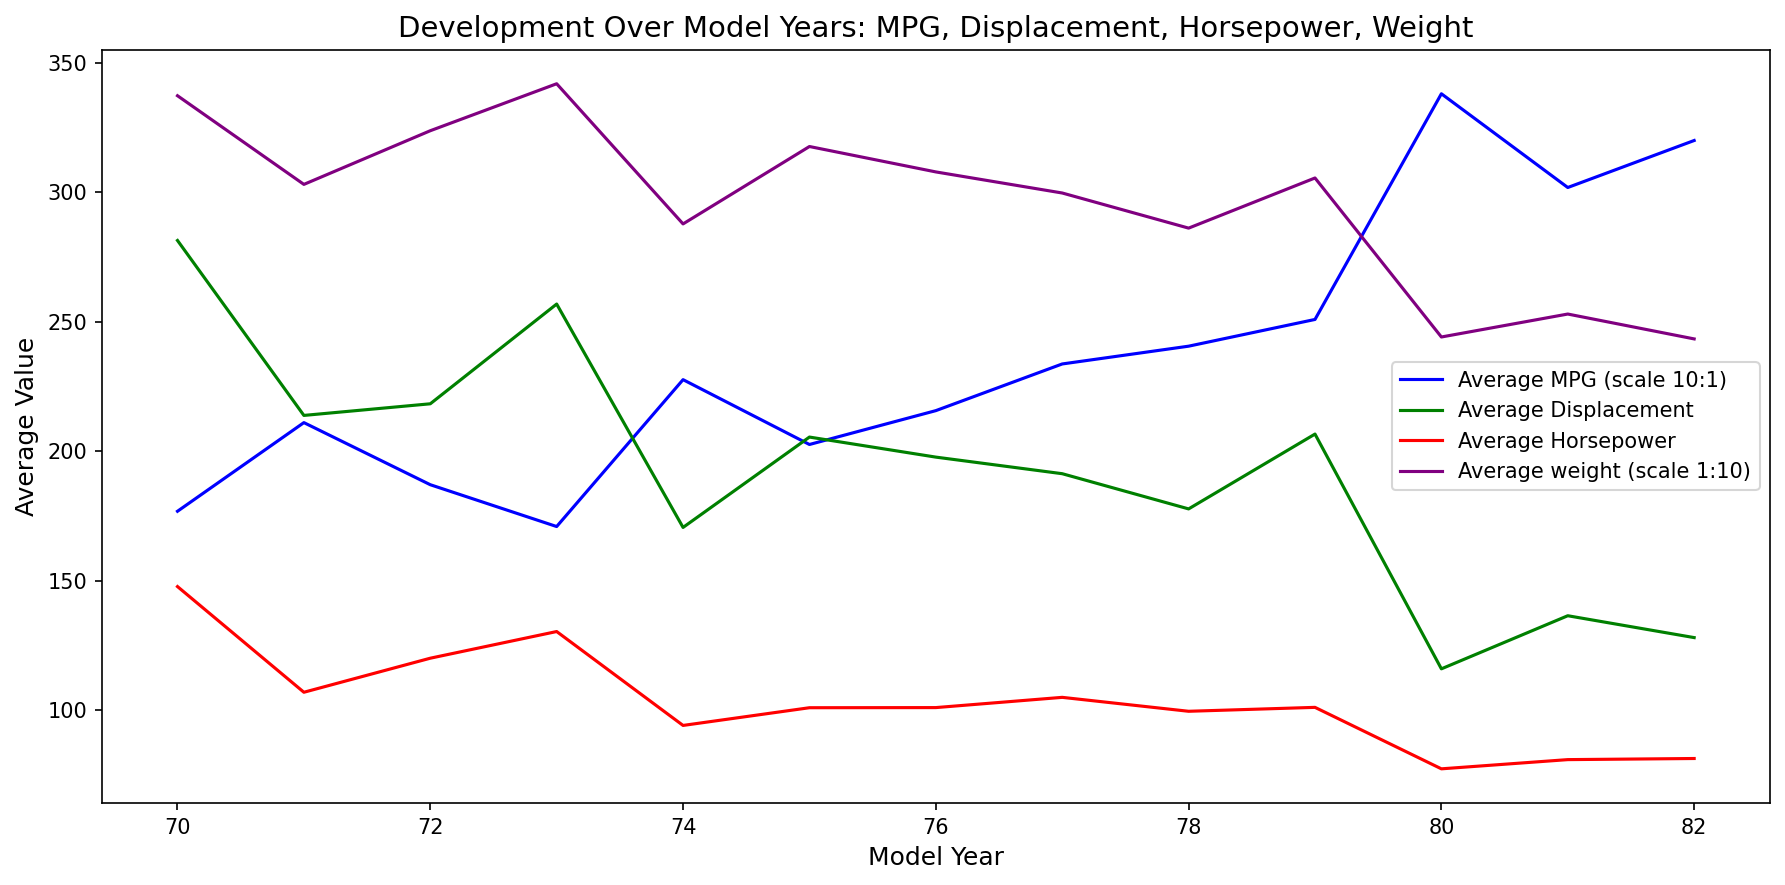

In [34]:
import matplotlib.pyplot as plt 

df_grouped = df_filtered.groupby("model_year").mean().reset_index()

df_scaled_weight = df_grouped["weight"]/10 # for easier view in regards to other features

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
plt.plot(df_grouped["model_year"], df_grouped["mpg"]*10, label="Average MPG (scale 10:1)", color="blue")
plt.plot(df_grouped["model_year"], df_grouped["displacement"], label="Average Displacement", color="green")
plt.plot(df_grouped["model_year"], df_grouped["horsepower"], label="Average Horsepower", color="red")
plt.plot(df_grouped["model_year"], df_scaled_weight, label="Average weight (scale 1:10)", color="purple")
# Add labels and title
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("Average Value", fontsize=12)
plt.title("Development Over Model Years: MPG, Displacement, Horsepower, Weight", fontsize=14)
plt.legend()
plt.tight_layout()

### d) Check if there are any columns you might want to drop.

#### dropped name and origin

# 1. Linear regression on mpg dataset


### a) We want to predict the "mpg", split up X and y, and perform train|test split using scikit-learn. Choose test_size of 0.2 and random_state 42. Control the shapes of each X_train, X_test, y_train, y_test.


In [35]:
# tuple unpacking 
# X - design matrix / feature matrix / features / independent variables
# y - target variable / label / dependent variable
X, y = df_filtered.drop("mpg", axis = "columns"), df_filtered["mpg"]
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70
2,8,318.0,150.0,3436,11.0,70
3,8,304.0,150.0,3433,12.0,70
4,8,302.0,140.0,3449,10.5,70


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(f"{X_train.shape = }")
print(f"{y_train.shape = }")
print(f"{X_test.shape = }")
print(f"{y_test.shape = }")

X_train.shape = (313, 6)
y_train.shape = (313,)
X_test.shape = (79, 6)
y_test.shape = (79,)


In [37]:
from sklearn.preprocessing import MinMaxScaler

# instantiate an instance from the MinMaxScaler class
scaler = MinMaxScaler()
type(scaler)

sklearn.preprocessing._data.MinMaxScaler

In [38]:
scaler

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [39]:
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.min() = }")
print(f"{scaled_X_train.max() = }")
print(f"{scaled_X_test.min() = }")
print(f"{scaled_X_test.max() = }")

scaled_X_train.min() = np.float64(0.0)
scaled_X_train.max() = np.float64(1.0)
scaled_X_test.min() = np.float64(-0.0051948051948051965)
scaled_X_test.max() = np.float64(1.0)



### b) Create a function for training a regression model, predicting and computing the metrics MAE, MSE, RMSE. It should take in parameters of X_train, X_test, y_train, y_test, model. Now create a linear regression model using scikit-learns LinearRegression() (OLS normal equation with SVD) and call your function to get metrics.

In [40]:
from sklearn.linear_model import LinearRegression

# instantiate an instance from LinearRegression class
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
model.fit(scaled_X_train, y_train)
print(f"Parameters or weights: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Parameters or weights: [ -0.580865     0.39018741  -0.41884721 -23.14066817   1.03715653
   9.12763733]
Intercept: 27.71548625915781


### Prediction

In [42]:
X_test.iloc[0]

cylinders          4.0
displacement      96.0
horsepower        69.0
weight          2189.0
acceleration      18.0
model_year        72.0
Name: 79, dtype: float64

In [43]:
sample_features = scaled_X_test[0].reshape(1, -1)
sample_features

array([[0.2       , 0.06753247, 0.125     , 0.1633116 , 0.5952381 ,
        0.16666667]])

In [44]:
model.predict(sample_features)

array([25.93279618])

In [45]:
y_test.iloc[0]

np.float64(26.0)

In [46]:
y_pred = model.predict(scaled_X_test)
y_pred[:5]

array([25.93279618, 26.29927859, 32.96548909, 26.8544302 , 29.45372581])

In [47]:
y_test.iloc[:5]

79     26.0
276    21.6
248    36.1
56     26.0
393    27.0
Name: mpg, dtype: float64

### 5. evaluate
common metrics for regression case

mae - mean absolute error
mse - mean squared error
rmse - root mean squared error

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np 

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"{mae = }")
print(f"{mse = }")
print(f"{rmse = }")

mae = 2.503860089776124
mse = 10.502370329417305
rmse = np.float64(3.240736078334258)
